# Multivariate HMM Regime Segmentation
Here we notebook implements a Multivariate Hidden Markov Model (HMM) approach to market regime segmentation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load data
data_path = r'../../../data/synthetic_regime_data.csv'
df = pd.read_csv(data_path)


df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

price_col = 'GSPC'
ret_col = 'Return'

print(f"Data loaded. Shape: {df.shape}")
df.head()

Data loaded. Shape: (2500, 11)


,Date,GSPC,Return,VIX,Drawdown,RSI_14,MACD_Hist,Consumer_Sentiment_ZScore,Gold,Oil,true_regime
0,2010-01-04,1000.000000,0.004965,14.152481,0.000000,NaN,0.000000,NaN,1800.000000,70.000000,bull
1,2010-01-05,1008.145477,0.008145,14.093172,0.000000,NaN,0.519825,NaN,1792.852257,69.041521,bull
2,2010-01-06,1005.876679,-0.002250,11.408714,-0.002250,NaN,0.672417,NaN,1789.745250,69.478473,bull
3,2010-01-07,991.825378,-0.013969,28.349549,-0.016188,NaN,-0.166628,NaN,1781.728894,67.994483,bear
4,2010-01-08,967.651309,-0.024373,33.664145,-0.040167,NaN,-2.228862,NaN,1783.837293,66.895061,bear


In [2]:
# Prepare data for the Multivariate HMM
#features = [ret_col, 'VIX', 'RSI_14', 'MACD_Hist']
features = [ret_col, 'VIX']
df_clean = df.dropna(subset=features).copy().reset_index(drop=True)
X_raw = df_clean[features].values

# Scale the features
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f"Features used: {features}")
print(f"Observation matrix shape: {X.shape}")
print(f"Scaled means: {X.mean(axis=0).round(4)}")
print(f"Scaled stds: {X.std(axis=0).round(4)}")

Features used: ['Return', 'VIX']
Observation matrix shape: (2500, 2)
Scaled means: [ 0. -0.]
Scaled stds: [1. 1.]


In [3]:
print("Fitting Multivariate Gaussian HMM (2 regimes)...")

# We use a Gaussian HMM with 2 components (Bull and Bear)
model = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
model.fit(X)
hidden_states = model.predict(X)
smoothed_probs = model.predict_proba(X)

print(f"Model converged: {model.monitor_.converged}")

Fitting Multivariate Gaussian HMM (2 regimes)...
Model converged: True


In [4]:
# Map states to Bull/Bear Regimes
means_scaled = model.means_
means_original = scaler.inverse_transform(means_scaled)

print("State 0 (Original Scale):")
print(f"  Mean Return: {means_original[0][0]:.6f}, Mean VIX: {means_original[0][1]:.6f}")
print("State 1 (Original Scale):")
print(f"  Mean Return: {means_original[1][0]:.6f}, Mean VIX: {means_original[1][1]:.6f}")

# define the Bull state as the one with the higher mean return
if means_original[0][0] > means_original[1][0]:
    bull_state = 0
    bear_state = 1
else:
    bull_state = 1
    bear_state = 0

print(f"\nAssigned State {bull_state} to Bull Regime")
print(f"Assigned State {bear_state} to Bear Regime")

# assign regime based on the highest probability
df_clean['prob_bull'] = smoothed_probs[:, bull_state]
df_clean['prob_bear'] = smoothed_probs[:, bear_state]
df_clean['regime'] = np.where(df_clean['prob_bull'] > 0.5, 'bull', 'bear')

if 'Regime' in df.columns:
    df = df.drop(columns=['Regime'])

df = df.merge(df_clean[['Date', 'regime', 'prob_bull', 'prob_bear']], on='Date', how='left')
first_regime = df_clean['regime'].iloc[0]
df['regime'] = df['regime'].fillna(first_regime)

print("\nMultivariate HMM regime mapping complete.")
print("\nRegime Counts:")
print(df['regime'].value_counts())
print("\nRegime Proportions:")
print(df['regime'].value_counts(normalize=True).round(3))

State 0 (Original Scale):
  Mean Return: 0.000300, Mean VIX: 14.948520
State 1 (Original Scale):
  Mean Return: -0.001739, Mean VIX: 29.680157

Assigned State 0 to Bull Regime
Assigned State 1 to Bear Regime

Multivariate HMM regime mapping complete.

Regime Counts:
regime
bull    1875
bear     625
Name: count, dtype: int64

Regime Proportions:
regime
bull    0.75
bear    0.25
Name: proportion, dtype: float64


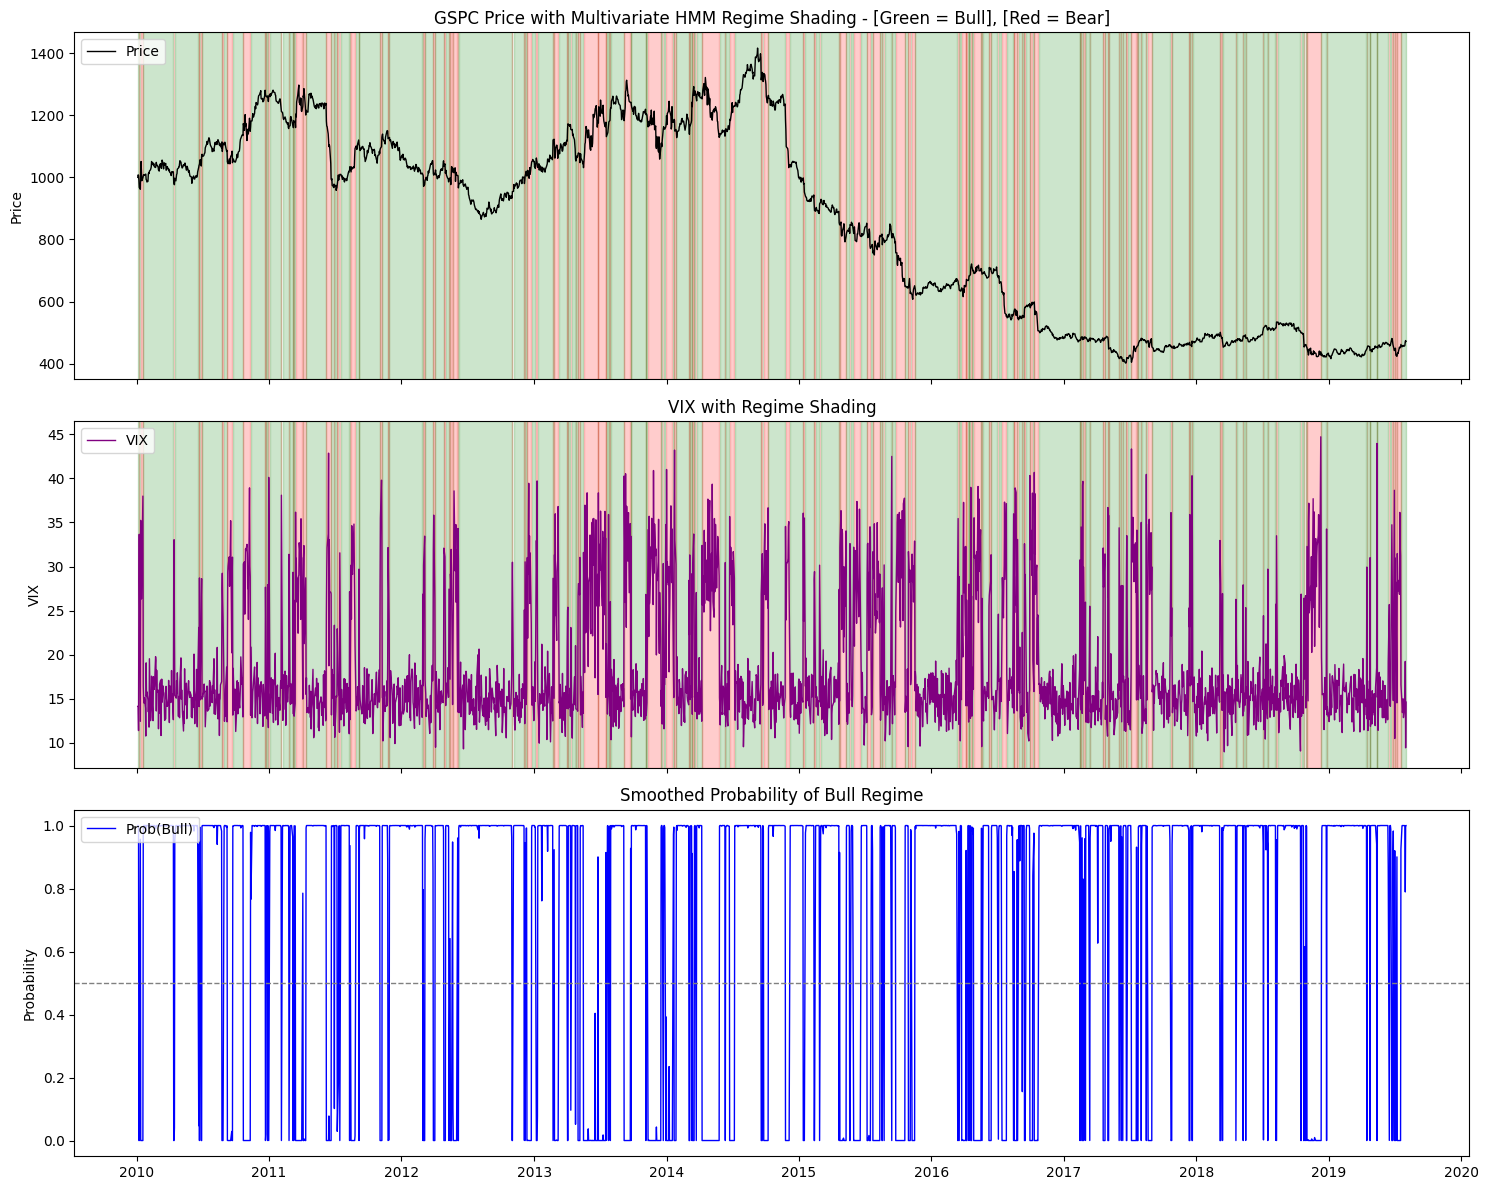

In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
ax1.plot(df['Date'], df[price_col], color='black', linewidth=1, label='Price')
ax1.set_title(f'{price_col} Price with Multivariate HMM Regime Shading - [Green = Bull], [Red = Bear]')
ax1.set_ylabel('Price')
ax1.legend(loc='upper left')


df['regime_change'] = (df['regime'] != df['regime'].shift(1)).cumsum()
for _, group in df.groupby('regime_change'):
    start_date = group['Date'].iloc[0]
    end_date = group['Date'].iloc[-1]
    regime = group['regime'].iloc[0]
    color = 'green' if regime == 'bull' else 'red'
    ax1.axvspan(start_date, end_date, color=color, alpha=0.2)

# Plot 2: VIX with regime shading
ax2.plot(df['Date'], df['VIX'], color='purple', linewidth=1, label='VIX')
ax2.set_title('VIX with Regime Shading')
ax2.set_ylabel('VIX')
ax2.legend(loc='upper left')

for _, group in df.groupby('regime_change'):
    start_date = group['Date'].iloc[0]
    end_date = group['Date'].iloc[-1]
    regime = group['regime'].iloc[0]
    color = 'green' if regime == 'bull' else 'red'
    ax2.axvspan(start_date, end_date, color=color, alpha=0.2)

# Plot 3: Smoothed Probability of Bull Regime
ax3.plot(df['Date'], df['prob_bull'], color='blue', linewidth=1, label='Prob(Bull)')
ax3.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
ax3.set_title('Smoothed Probability of Bull Regime')
ax3.set_ylabel('Probability')
ax3.set_ylim(-0.05, 1.05)
ax3.legend(loc='upper left')

plt.tight_layout()
plt.show()
df = df.drop(columns=['regime_change'])

In [7]:
missing_regimes = df['regime'].isna().sum()
assert missing_regimes == 0, f"Error: Found {missing_regimes} missing values in 'regime' column!"
print("Validation passed: No missing values in 'regime' column.")

output_csv = r'../../../data/synthetic/multivariate_hmm_labeled_dataset.csv'
df.to_csv(output_csv, index=False)
print(f"Dataset saved to {output_csv}")

Validation passed: No missing values in 'regime' column.
Dataset saved to ../../../data/synthetic/multivariate_hmm_labeled_dataset.csv


In [8]:
# =============================================================================
# EVALUATION CELL — Compare predicted regimes to synthetic ground truth
# =============================================================================
# Paste this cell at the END of each notebook (HMM, GMM, Changepoint)
# after the regime column has been assigned.
#
# Requirements:
#   - df must have a 'regime' column (predicted: 'bull' or 'bear')
#   - The synthetic CSV must have been loaded, so df also has 'true_regime'
#
# For HMM and Changepoint: the regime column is on df
# For GMM: the regime column is on df_work, so uncomment the line below:
# df = df_work.copy()  # <-- UNCOMMENT THIS FOR GMM NOTEBOOK ONLY

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# --- Align predicted and true labels ---
predicted = df['regime'].values
true = df['true_regime'].values

# Drop rows where either is NaN (shouldn't happen, but just in case)
mask = pd.notna(predicted) & pd.notna(true)
predicted = predicted[mask]
true = true[mask]

# --- Overall Accuracy ---
accuracy = accuracy_score(true, predicted)
print(f"Overall Accuracy: {accuracy:.4f} ({accuracy:.1%})")

# --- Per-regime Precision, Recall, F1 ---
print(f"\nClassification Report:")
print(classification_report(true, predicted, target_names=['bear', 'bull']))

# --- Confusion Matrix ---
cm = confusion_matrix(true, predicted, labels=['bear', 'bull'])
cm_df = pd.DataFrame(cm, index=['True Bear', 'True Bull'], columns=['Pred Bear', 'Pred Bull'])
print("Confusion Matrix:")
print(cm_df)

# --- Key insight: Bear recall (how many true crises were caught?) ---
bear_recall = recall_score(true, predicted, pos_label='bear')
bear_precision = precision_score(true, predicted, pos_label='bear')
print(f"\nBear Recall (crisis detection rate):  {bear_recall:.4f}")
print(f"Bear Precision (false alarm rate):    {bear_precision:.4f}")
print(f"  -> Of all true bear days, the model caught {bear_recall:.1%}")
print(f"  -> Of all days labelled bear, {bear_precision:.1%} were actually bear")

# --- Detection Lag (how many days after a true regime switch does the model react?) ---
regime_switches = np.where(true[1:] != true[:-1])[0] + 1
lags = []
for switch_idx in regime_switches:
    new_true_regime = true[switch_idx]
    # Look forward: how many days until predicted matches?
    for offset in range(0, min(60, len(true) - switch_idx)):
        if predicted[switch_idx + offset] == new_true_regime:
            lags.append(offset)
            break
    else:
        lags.append(np.nan)  # Never detected within 60 days

lags = np.array(lags, dtype=float)
valid_lags = lags[~np.isnan(lags)]

print(f"\n--- Detection Lag Analysis ---")
print(f"Total regime switches in ground truth: {len(regime_switches)}")
print(f"Switches detected within 60 days:      {len(valid_lags)}/{len(regime_switches)}")
if len(valid_lags) > 0:
    print(f"Mean detection lag:  {np.mean(valid_lags):.1f} days")
    print(f"Median detection lag: {np.median(valid_lags):.1f} days")

Overall Accuracy: 0.9944 (99.4%)

Classification Report:
              precision    recall  f1-score   support

        bear       0.99      0.99      0.99       625
        bull       1.00      1.00      1.00      1875

    accuracy                           0.99      2500
   macro avg       0.99      0.99      0.99      2500
weighted avg       0.99      0.99      0.99      2500

Confusion Matrix:
           Pred Bear  Pred Bull
True Bear        618          7
True Bull          7       1868

Bear Recall (crisis detection rate):  0.9888
Bear Precision (false alarm rate):    0.9888
  -> Of all true bear days, the model caught 98.9%
  -> Of all days labelled bear, 98.9% were actually bear

--- Detection Lag Analysis ---
Total regime switches in ground truth: 292
Switches detected within 60 days:      292/292
Mean detection lag:  0.1 days
Median detection lag: 0.0 days
